# Predicting House Prices in California with `LinearRegression()`

In this lab you will start inspect, analyze, visualize house price data from different districts in California, US. After having performed analysis, EDA and some feature engineering, you will build your own `LinearRegression()`  with `SkLearn`. 

In [244]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Part 1 - Inspection and Cleaning


#### Import and Inspect your data

Read the `housing.csv` file and make use of some methods to understand your data better. Below is an explanation of the features you are going to work with:

1. **longitude:**  geographical coordinate, east to west position of district
2. **latitude:**  geographical coordinate, north to south position of district
3. **housing_median_age:** the median age of houses in district
4. **total_rooms** Sum of all rooms in district
5. **total_bedrooms** Sum of all bedrooms in district
6. **population:** total population in district
7. **households:** total households in district
8. **median_income:** median household income in district 
9. **median_house_value:** median house value in district
10. **ocean_proximity:** District´s proximity to the ocean

In [245]:
data = pd.read_csv('../data/housing.csv')

In [246]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [247]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [248]:
data.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


#### Histograms
Make histograms of all your numeric columns in order to get a good understanding of the distribution of your data points. What do you see?

<Figure size 3000x1500 with 0 Axes>

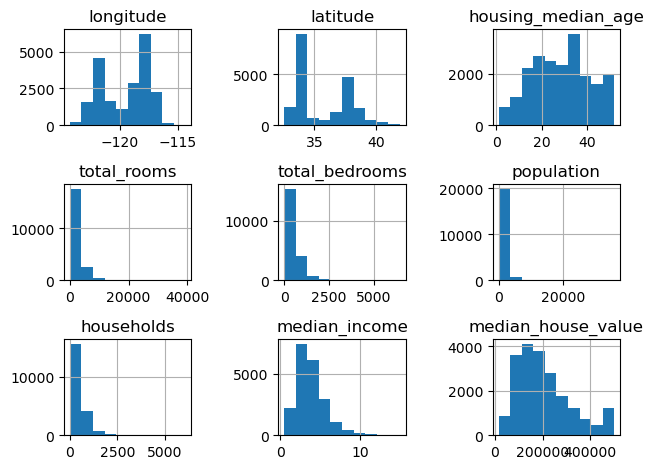

In [249]:
fig = plt.figure(figsize=(30, 15))
viz = data[['longitude','latitude','housing_median_age','total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']]
viz.hist()
plt.tight_layout()
plt.show()

#### Let's create some features a tidy up our data

1. Locate your NaN values and make a decision on how to handle them. Drop, fill with mean, or something else, it is entirely up to you. 

In [250]:
# There are only 207 records out of a total of 20640 for a linear model that has enough data to perform well.
# Therefore, it's best to filter them
print(data.isna().sum())
print(data.shape)

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
(20640, 10)


In [251]:
data.dropna(subset=["total_bedrooms"], inplace=True)
print(data.isna().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


2. Create three new columns by using simple arithmetic operations. Create one column with "rooms per household", one with "population per household",  and one with "bedrooms per room".

In [252]:
data['rooms_per_household'] = data['total_rooms'] * data['households']
data['rooms_per_household'].head(5)

0     110880.0
1    8078662.0
2     259659.0
3     279006.0
4     421393.0
Name: rooms_per_household, dtype: float64

In [253]:
data['population_per_household'] = data['population'] * data['households']
data['population_per_household'].head(5)

0      40572.0
1    2732338.0
2      87792.0
3     122202.0
4     146335.0
Name: population_per_household, dtype: float64

In [254]:
data['bedrooms_per_room'] = data['total_bedrooms'] * data['total_rooms']
data['bedrooms_per_room'].head(5)

0     113520.0
1    7851494.0
2     278730.0
3     299390.0
4     455560.0
Name: bedrooms_per_room, dtype: float64

3. If you check the largest and smallest values of your "rooms per houshold column" you will see two outliers and two values that are just wrong. Drop the four values by index.

In [255]:
print(data['rooms_per_household'].min())
print(data['rooms_per_household'].max())
data.drop(index=[data['rooms_per_household'].argmin(), data['rooms_per_household'].argmax()], inplace=True)

4.0
210676560.0


# Part 2 - Exploratory Data Analysis



#### Let's find out what factors have an influence on our predicting variable

1. Let's check out the distribution of our "median house value". Visualize your results with 100 bins.

In [256]:
data['median_house_value'].head(100)

0     452600.0
1     358500.0
2     352100.0
3     341300.0
4     342200.0
        ...   
95    130000.0
96    183800.0
97    125000.0
98    170000.0
99    193100.0
Name: median_house_value, Length: 100, dtype: float64

2. Check out what variables correlates the most with "median house value"

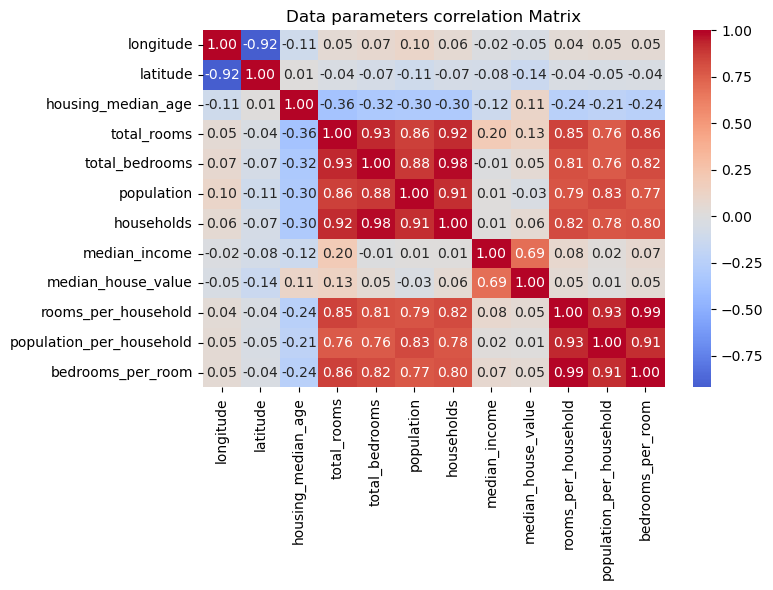

In [257]:
data_clean = data.drop(['ocean_proximity'], axis=1)
plt.figure(figsize=(8, 6))
sns.heatmap(data_clean.corr().round(2), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Data parameters correlation Matrix')
plt.tight_layout()
plt.show()

# median_income

3. Let's check out the distribution of the column that has the highest correlation to "median house value". Visualize your results with 100 bins.

In [258]:
data_clean['median_income'].head(100)

0     8.3252
1     8.3014
2     7.2574
3     5.6431
4     3.8462
       ...  
95    2.0096
96    2.8345
97    2.0062
98    1.2185
99    2.6104
Name: median_income, Length: 100, dtype: float64

4. Visualize the "median house value" and "median income" in a jointplot (kind="reg"). What do you see?

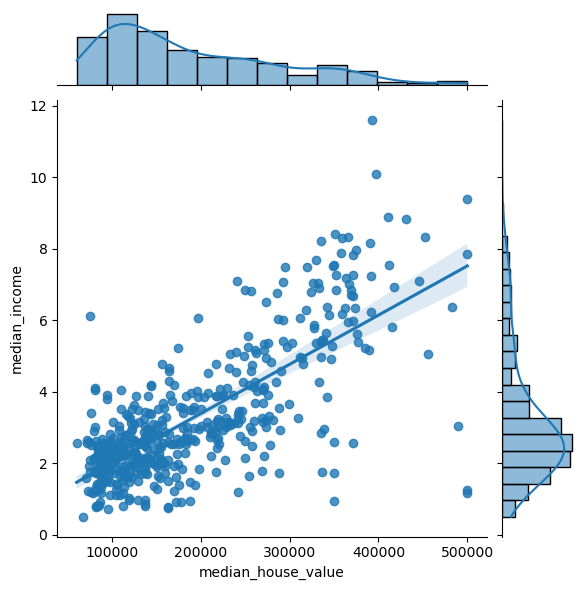

In [259]:
sns.jointplot(data=data_clean[0:500], x="median_house_value", y="median_income", kind="reg")

plt.show()

# Big outliner on high median_house_value

5. Make the same visualization as in the above, but, cahnge the kind parameter to "kde". What extra information does this type of visualization convey, that the one in the above does not?

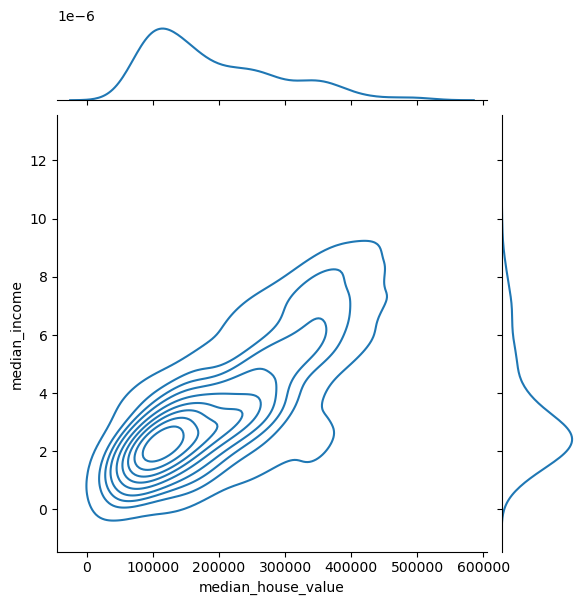

In [260]:

sns.jointplot(data=data[0:500], x="median_house_value", y="median_income", kind="kde")

plt.show()

#### Let's get schwifty with some EDA

1. Create a new categorical column from the "median income" with the following quartiles `[0, 0.25, 0.5, 0.75, 0.95, 1]` and label them like this `["Low", "Below_Average", "Above_Average", "High", "Very High"]` and name the column "income_cat"

In [261]:
data['income_cat'] = pd.qcut(data['median_income'], [0, 0.25, 0.5, 0.75, 0.95, 1], labels=["Low", "Below_Average", "Above_Average", "High", "Very High"])
display(data.sample(10))

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,population_per_household,bedrooms_per_room,income_cat
6024,-117.76,34.05,36.0,3839.0,1004.0,4711.0,942.0,2.3859,116200.0,INLAND,3616338.0,4437762.0,3854356.0,Low
12250,-116.98,33.77,12.0,5829.0,1309.0,2711.0,1118.0,1.9707,107900.0,INLAND,6516822.0,3030898.0,7630161.0,Low
9991,-121.10,39.08,13.0,1110.0,216.0,602.0,209.0,2.5887,144400.0,INLAND,231990.0,125818.0,239760.0,Below_Average
16932,-122.32,37.56,44.0,537.0,173.0,355.0,194.0,2.8571,250000.0,NEAR OCEAN,104178.0,68870.0,92901.0,Below_Average
17436,-120.47,34.64,16.0,1912.0,406.0,1009.0,417.0,3.4063,138000.0,NEAR OCEAN,797304.0,420753.0,776272.0,Below_Average
8184,-118.10,33.78,35.0,4466.0,740.0,2134.0,743.0,5.7389,251800.0,<1H OCEAN,3318238.0,1585562.0,3304840.0,High
7350,-118.16,33.97,31.0,1363.0,428.0,1897.0,364.0,2.3929,191100.0,<1H OCEAN,496132.0,690508.0,583364.0,Low
18850,-122.32,41.31,45.0,1393.0,294.0,521.0,249.0,1.1915,71900.0,INLAND,346857.0,129729.0,409542.0,Low
13258,-117.69,34.10,17.0,3759.0,1035.0,1722.0,847.0,2.6074,137500.0,INLAND,3183873.0,1458534.0,3890565.0,Below_Average
130,-122.21,37.84,34.0,3038.0,490.0,1140.0,496.0,7.0548,325900.0,NEAR BAY,1506848.0,565440.0,1488620.0,High


2. Using the Seaborn library, plot the count of your new column and set the `hue` to "ocean_proximity". What interesting things can you see?

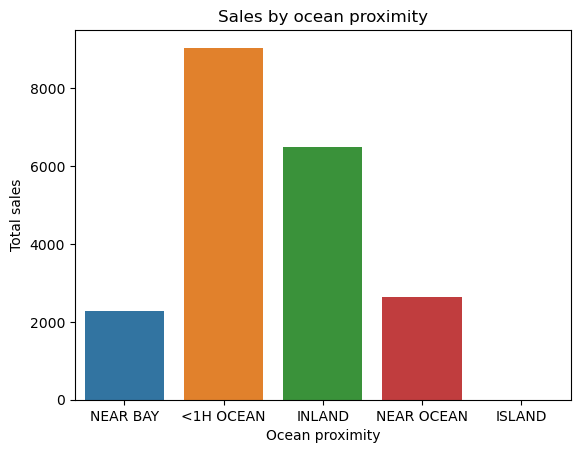

In [262]:
sns.countplot(data=data, x='ocean_proximity', hue='ocean_proximity')

plt.title('Sales by ocean proximity')
plt.xlabel('Ocean proximity')
plt.ylabel('Total sales')

plt.show()

3. Create two barplots where you set "y="median_house_value" on both, and the x is first "income cat" and then "ocean_proximity". How does these two graphs complement what you saw in the graph in your previous question?

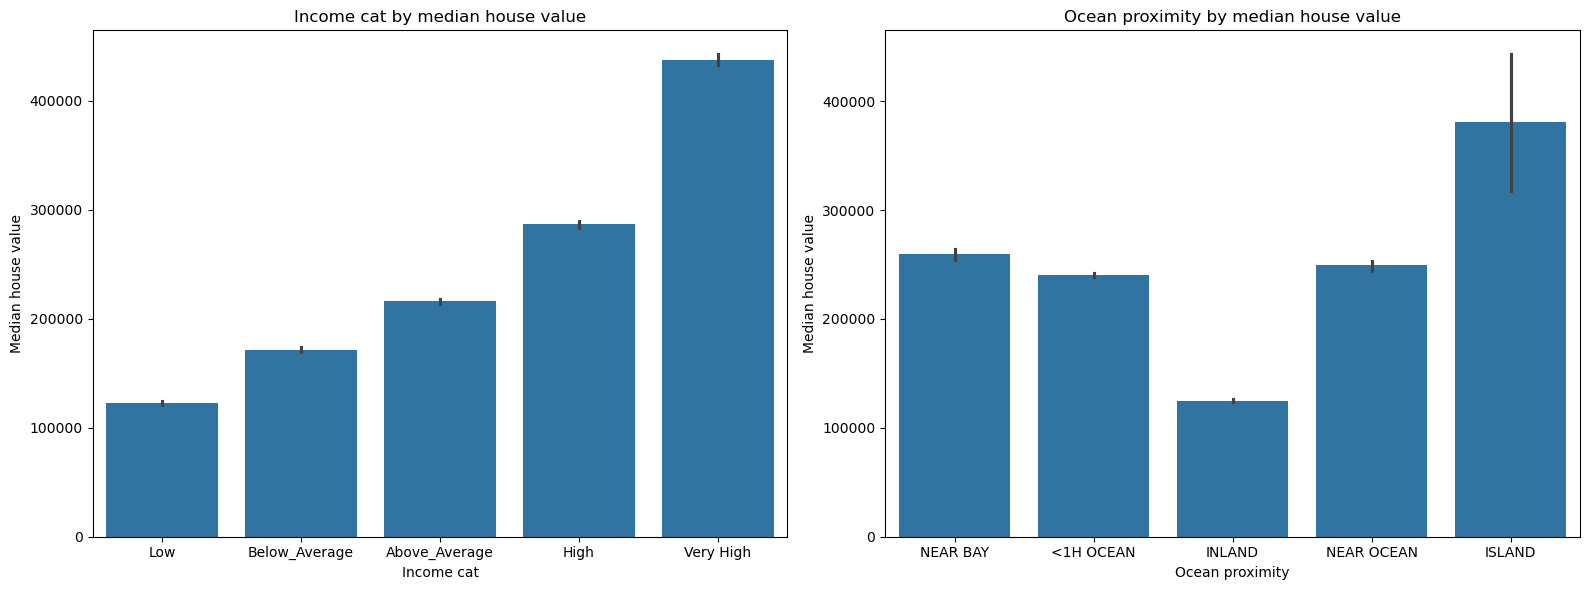

In [263]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sns.barplot(data=data, x='income_cat', y='median_house_value', ax=axes[0])
axes[0].set_title('Income cat by median house value')
axes[0].set_xlabel('Income cat')
axes[0].set_ylabel('Median house value')

sns.barplot(data=data, x='ocean_proximity', y='median_house_value', ax=axes[1])
axes[1].set_title('Ocean proximity by median house value')
axes[1].set_xlabel('Ocean proximity')
axes[1].set_ylabel('Median house value')

plt.tight_layout()
plt.show()

### People with higher incomes tend to live on islands or closer to the sea

4. Create a pivoted dataframe where you have the values of the "income cat" column as indices and the values of the "ocean_proximity" column as columns. Also drop the "ISLAND" column that you'll get.

In [264]:
data_pivoted = data.pivot_table(index='income_cat', columns='ocean_proximity', values='median_house_value', fill_value=0)
data_pivoted_clean = data_pivoted.drop('ISLAND', axis=1)
display(data_pivoted_clean)

C:\Users\agcor\AppData\Local\Temp\ipykernel_7984\4050708521.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  data_pivoted = data.pivot_table(index='income_cat', columns='ocean_proximity', values='median_house_value', fill_value=0)


ocean_proximity,<1H OCEAN,INLAND,NEAR BAY,NEAR OCEAN
income_cat,,,,
Low,161359.099394,84820.626650,155122.052133,148027.826514
Below_Average,197201.582936,115125.900763,220196.177656,208665.190096
Above_Average,232278.358759,147820.944246,261972.645008,255293.813584
High,292208.766217,208076.692722,322437.049407,337446.227778
Very High,439784.235489,347571.736842,451015.078788,468739.723270


5. Turn your pivoted dataframe into a heatmap. The heatmap should have annotations in integer format.

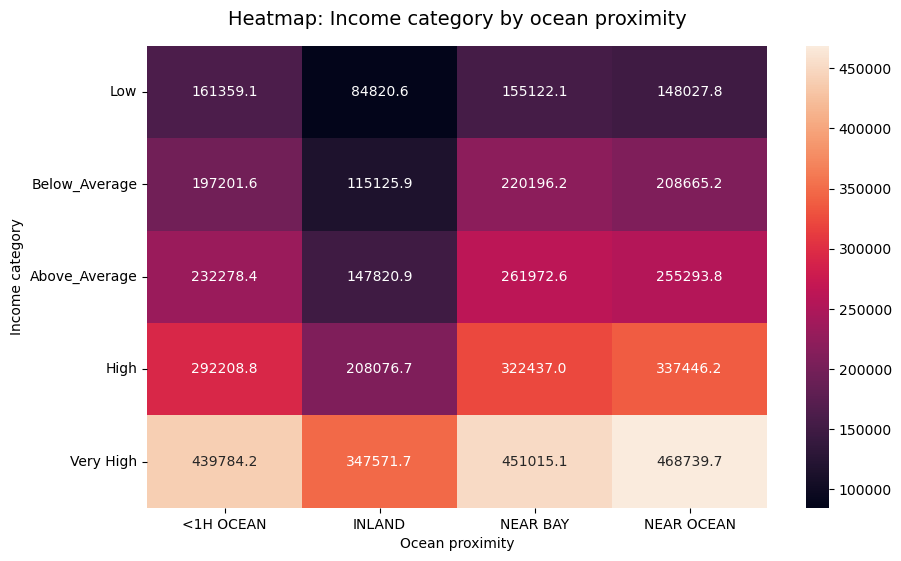

In [265]:
plt.figure(figsize=(10, 6))

sns.heatmap(data_pivoted_clean, annot=True, fmt=".1f", cbar=True)

plt.title('Heatmap: Income category by ocean proximity', fontsize=14, pad=15)
plt.xlabel('Ocean proximity')
plt.ylabel('Income category')

plt.show()

# Part 3 - Preparing your Data



#### Splitting, Preparing and Engineering some Features

1. Let's drop the "income_cat" column as it has served its purpose already. We don't need for our model as we already have "median income".
Not dropping "incom cat" will lead to multicolinearity.

In [266]:
data_clean = data.drop('income_cat', axis=1)
display(data_clean)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,population_per_household,bedrooms_per_room
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,110880.0,40572.0,113520.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,8078662.0,2732338.0,7851494.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,259659.0,87792.0,278730.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,279006.0,122202.0,299390.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,421393.0,146335.0,455560.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,549450.0,278850.0,622710.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,79458.0,40584.0,104550.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,975982.0,436031.0,1093190.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,649140.0,258609.0,760740.0


2. Select your floating point columns and standardize your data by calculating the Z-score. You can apply the `stats.zscore()` method in a lambda function. Save your results to a variable called `z_scored`. 

In [267]:
import scipy.stats as stats

data_clean_float = data_clean.drop(['ocean_proximity'], axis=1)
z_scored = data_clean_float.apply(stats.zscore)
display(z_scored)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,population_per_household,bedrooms_per_room
0,-1.327292,1.051789,0.982077,-0.803743,-0.970249,-0.973248,-0.976751,2.345273,2.128762,-0.337774,-0.336238,-0.333404
1,-1.322301,1.042427,-0.606379,2.042357,1.348299,0.861384,1.670407,2.332741,1.313584,1.026031,0.514369,0.860394
2,-1.332283,1.037746,1.855728,-0.535105,-0.825488,-0.819700,-0.843346,1.783046,1.258142,-0.312308,-0.321316,-0.307915
3,-1.337274,1.037746,1.855728,-0.623431,-0.718697,-0.764988,-0.733484,0.933073,1.164582,-0.308996,-0.310443,-0.304728
4,-1.337274,1.037746,1.855728,-0.461882,-0.611906,-0.758811,-0.628853,-0.013045,1.172379,-0.284625,-0.302817,-0.280635
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-0.758302,1.800750,-0.288688,-0.444491,-0.388832,-0.511722,-0.443134,-1.216634,-1.115491,-0.262706,-0.260941,-0.254847
20636,-0.818196,1.805431,-0.844647,-0.887492,-0.920413,-0.943244,-1.008140,-0.691949,-1.124153,-0.343152,-0.336234,-0.334788
20637,-0.823187,1.777345,-0.924070,-0.174938,-0.125414,-0.368764,-0.173710,-1.143078,-0.992478,-0.189699,-0.211272,-0.182262
20638,-0.873098,1.777345,-0.844647,-0.355250,-0.305772,-0.603498,-0.393434,-1.055043,-1.058315,-0.245643,-0.267338,-0.233552


3. Turn the only categorical columns into dummies. Be vary of the dummy trap, to avoid multicolinearity.

In [268]:
data_numeric_clean = pd.get_dummies(data=data_clean, columns=['ocean_proximity'], drop_first=True, dtype=int)
data_numeric_clean

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,population_per_household,bedrooms_per_room,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,110880.0,40572.0,113520.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,8078662.0,2732338.0,7851494.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,259659.0,87792.0,278730.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,279006.0,122202.0,299390.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,421393.0,146335.0,455560.0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,549450.0,278850.0,622710.0,1,0,0,0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,79458.0,40584.0,104550.0,1,0,0,0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,975982.0,436031.0,1093190.0,1,0,0,0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,649140.0,258609.0,760740.0,1,0,0,0


4. Save our predicting variable to `y`.

In [269]:
y = data_numeric_clean.drop(['median_income'], axis=1)

5. Concatenate `z_scored` and `dummies` and drop the predicting variable. Save to the varible `X`.

In [270]:
x_data_scored = z_scored.drop(columns=['median_income'])
dummies = data_numeric_clean[['ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']]
X = pd.concat([x_data_scored, dummies], axis=1)
X


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_house_value,rooms_per_household,population_per_household,bedrooms_per_room,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.327292,1.051789,0.982077,-0.803743,-0.970249,-0.973248,-0.976751,2.128762,-0.337774,-0.336238,-0.333404,0,0,1,0
1,-1.322301,1.042427,-0.606379,2.042357,1.348299,0.861384,1.670407,1.313584,1.026031,0.514369,0.860394,0,0,1,0
2,-1.332283,1.037746,1.855728,-0.535105,-0.825488,-0.819700,-0.843346,1.258142,-0.312308,-0.321316,-0.307915,0,0,1,0
3,-1.337274,1.037746,1.855728,-0.623431,-0.718697,-0.764988,-0.733484,1.164582,-0.308996,-0.310443,-0.304728,0,0,1,0
4,-1.337274,1.037746,1.855728,-0.461882,-0.611906,-0.758811,-0.628853,1.172379,-0.284625,-0.302817,-0.280635,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-0.758302,1.800750,-0.288688,-0.444491,-0.388832,-0.511722,-0.443134,-1.115491,-0.262706,-0.260941,-0.254847,1,0,0,0
20636,-0.818196,1.805431,-0.844647,-0.887492,-0.920413,-0.943244,-1.008140,-1.124153,-0.343152,-0.336234,-0.334788,1,0,0,0
20637,-0.823187,1.777345,-0.924070,-0.174938,-0.125414,-0.368764,-0.173710,-0.992478,-0.189699,-0.211272,-0.182262,1,0,0,0
20638,-0.873098,1.777345,-0.844647,-0.355250,-0.305772,-0.603498,-0.393434,-1.058315,-0.245643,-0.267338,-0.233552,1,0,0,0


# Part 4 - Machine Learning 




#### Train, Test, Split

1. Import `train_test_split` and split your data accordingly. Choose an appropriate test size.

In [271]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Building and Training our Model

2. Build, fit and train a `LinearRegression` model. 

In [272]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(X_train, y_train)

3. In a scatterplot, visualize the y_train on your x-axis and your predictions on the y-axis. How does your training predictions look? 

(16344, 15)
(4087, 15)


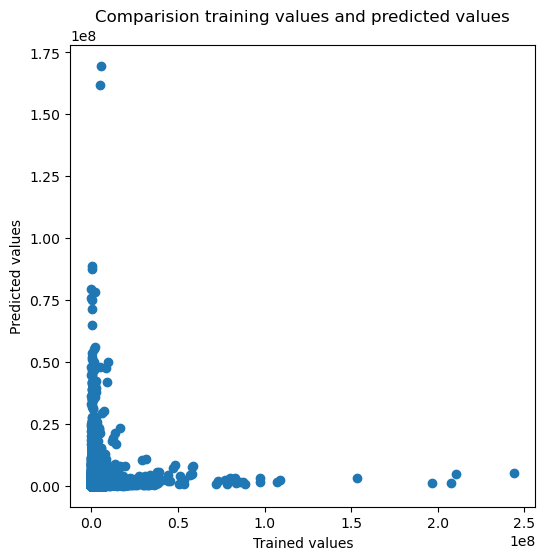

In [277]:
y_pred = model.predict(X_test)
print(y_train.shape)
print(y_pred.shape)

plt.figure(figsize=(6, 6))
plt.scatter(y_train[0:4087], y_pred, label='Predictions')

plt.xlabel('Trained values')
plt.ylabel('Predicted values')
plt.title('Comparision training values and predicted values')

plt.show()

### The cluster points looks curved seems the model has high bias

4. From the sklearn metrics module, print the mean_squared_error and R^2-score. What does the metrics tell us?

In [279]:
from sklearn.metrics import r2_score, mean_squared_error

print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")


MSE: 0.00
R²: 1.0000


### It seems that the model suffers from severe overfitting, since the R-squared value is perfect and the mean squared error value is as well

#### Final Predictions

1. Now you are ready to make prediction on the test data. Do that and visualize your results in a new scatterplot.

2. Print the mean_squared_error and R^2-score again. What has happened?

3. There is another metric called Root mean squared error, Which is the square root of the MSE. Calculate the RMSE.

# Bonus Questions 1

1. Create a dataframe with two columns, one consisting of the y_test and one of your model's predictions.

2. Make a series of of your new dataframe, by calculating the predicted error in absolut numbers. Save this series to variable name `absolute_errors`.

3. If you take the mean of your series, you will get the mean absolute errors, which is another metric for Linear Regressions.

# Bonus Question 2 - Build a Random Forest Regressor

1. Build, fit and train a `RandomForestRegressor` model. Do this by following the same staps that you followed when building your `LinearRegression`.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

2. Make prediction on the test data and evaluate you results.